In [5]:
import numpy as np
import netket as nk
import matplotlib.pyplot as plt
import time
from netket.operator.fermion import destroy as c
from netket.operator.fermion import create as cdag
def ED(handle, k=5, which="SA"):
    hi = H.hilbert
    if hi.n_states>1e3: #sparse matrix
        sp_h = H.to_sparse()
        eig_vals, eig_vecs = eigsh(sp_h, k=k, which=which)
        sort_idx = np.argsort(eig_vals)
        eig_vals_sorted = eig_vals[sort_idx]
        eig_vecs_sorted = eig_vecs[:, sort_idx]
    else:
        eig_vals_sorted, eig_vecs_sorted = np.linalg.eigh(H.to_dense())
    E0 = np.min(eig_vals_sorted)
    degeneracy = np.sum(np.abs(eig_vals_sorted - E0) < 1e-8)
    return eig_vals_sorted, eig_vecs_sorted, degeneracy

In [ ]:
# Parameters
extent = [2,2]
# Graph and Hilbert space
graph =  nk.graph.Kagome(extent=extent,pbc=False)
hi = nk.hilbert.Spin(s=1/2, N=graph.n_nodes)
ha = nk.operator.Heisenberg(hi, graph, J=1.0, sign_rule=None)

# ED

In [7]:
# compute the ground-state energy (here we only need the lowest energy, and do not need the eigenstate)
evals = nk.exact.lanczos_ed(ha, compute_eigenvectors=False)
exact_gs_energy = evals[0]
print('The exact ground-state energy is E0=',exact_gs_energy)

The exact ground-state energy is E0= -18.853211390776416


# The Jastrow ansatz

In [ ]:
from flax import nnx
import jax.numpy as jnp
import jax

# class Jastrow(nnx.Module):
#     def __init__(self, N: int, *, rngs: nnx.Rngs):
#         k1, k2 = jax.random.split(rngs.params())
#         self.J = nnx.Param(0.01 * jax.random.normal(k1, (N, N),
#                                                     dtype=jnp.complex128))

#         self.v_bias = nnx.Param(0.01 * jax.random.normal(k2, (N, 1),
#                                                          dtype=jnp.complex128))

#     def __call__(self, x):
#         x = x.astype(jnp.complex128)              # keep the dtypes aligned
#         quad = jnp.einsum('...i,ij,...j->...', x, self.J, x)
#         lin  = jnp.squeeze(x @ self.v_bias, -1)   # (...,N) @ (N,1) → (...,1)
#         return quad + lin
# ma = Jastrow(N=hi.size, rngs=nnx.Rngs(0))
# or just:  
ma = nk.models.Jastrow()

In [13]:
# Build the sampler
sa = nk.sampler.MetropolisExchange(hilbert=hi,graph=graph)

# Optimizer
op = nk.optimizer.Sgd(learning_rate=0.01)

# Stochastic Reconfiguration
sr = nk.optimizer.SR(diag_shift=0.1, holomorphic=True)

# The variational state
vs = nk.vqs.MCState(sa, ma, n_samples=1008)

# The ground-state optimization loop
gs = nk.VMC(
    hamiltonian=ha,
    optimizer=op,
    preconditioner=sr,
    variational_state=vs)

start = time.time()
gs.run(300, out='Jastrow')
end = time.time()

print('### Jastrow calculation')
print('Has',nk.jax.tree_size(vs.parameters),'parameters')
print('The Jastrow calculation took',end-start,'seconds')

100%|██████████| 300/300 [00:09<00:00, 32.68it/s, Energy=-14.55+0.00j ± 0.12 [σ²=15.66, R̂=1.3816]] 

### Jastrow calculation
Has 156 parameters
The Jastrow calculation took 10.688110113143921 seconds


# RBM

In [40]:
# RBM ansatz with alpha=1
ma = nk.models.RBM(alpha=1)

geometric frustration

In [42]:
# Build the sampler
sa = nk.sampler.MetropolisExchange(hilbert=hi,graph=graph)

# Optimizer
op = nk.optimizer.Sgd(learning_rate=0.05)

# Stochastic Reconfiguration
sr = nk.optimizer.SR(diag_shift=0.1)

# The variational state
vs = nk.vqs.MCState(sa, ma, n_samples=1008)

# The ground-state optimization loop
gs = nk.VMC(
    hamiltonian=ha,
    optimizer=op,
    preconditioner=sr,
    variational_state=vs)

start = time.time()
gs.run(out='RBM', n_iter=300)
end = time.time()

print('### RBM calculation')
print('Has',vs.n_parameters,'parameters')
print('The RBM calculation took',end-start,'seconds')

100%|██████████| 300/300 [00:06<00:00, 43.36it/s, Energy=-4.45 ± 0.12 [σ²=14.69, R̂=1.4028]]

### RBM calculation
Has 168 parameters
The RBM calculation took 6.949383735656738 seconds


# RBM with Lattice symmetry

In [45]:
## Symmetric RBM Spin Machine
ma = nk.models.RBMSymm(symmetries=graph.translation_group(), alpha=1)

# Metropolis Exchange Sampling
# Notice that this sampler exchanges two neighboring sites
# thus preservers the total magnetization
sa = nk.sampler.MetropolisExchange(hi, graph=graph)

# Optimizer
op = nk.optimizer.Sgd(learning_rate=0.01)

# Stochastic Reconfiguration
sr = nk.optimizer.SR(diag_shift=0.1)

# The variational state
vs = nk.vqs.MCState(sa, ma, n_samples=1008)

# The ground-state optimization loop
gs = nk.VMC(
    hamiltonian=ha,
    optimizer=op,
    preconditioner=sr,
    variational_state=vs)

start = time.time()
gs.run(out='RBMSymmetric', n_iter=300)
end = time.time()

print('### Symmetric RBM calculation')
print('Has',vs.n_parameters,'parameters')
print('The Symmetric RBM calculation took',end-start,'seconds')

100%|██████████| 300/300 [00:06<00:00, 43.36it/s, Energy=-6.371 ± 0.053 [σ²=2.858, R̂=1.4086]]

### Symmetric RBM calculation
Has 157 parameters
The Symmetric RBM calculation took 8.263668537139893 seconds


# Compare

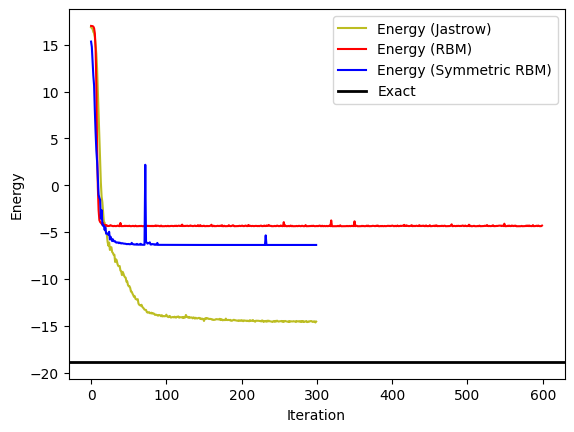

In [50]:
## import the data from log file
data=json.load(open("RBMSymmetric.log"))

# Extract the relevant information
iters_symRBM = data["Energy"]["iters"]
energy_symRBM = data["Energy"]["Mean"]

fig, ax1 = plt.subplots()
ax1.plot(iters_Jastrow, energy_Jastrow, color='C8', label='Energy (Jastrow)')
ax1.plot(iters_RBM, energy_RBM, color='red', label='Energy (RBM)')
ax1.plot(iters_symRBM, energy_symRBM, color='blue', label='Energy (Symmetric RBM)')

ax1.set_ylabel('Energy')
ax1.set_xlabel('Iteration')
if exact_gs_energy:
    # plt.axis([0,iters_symRBM[-1],exact_gs_energy-0.06,exact_gs_energy+0.12])
    plt.axhline(y=exact_gs_energy, xmin=0,
                    xmax=iters_RBM[-1], linewidth=2, color='k', label='Exact')
ax1.legend()
plt.show()